In [2]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional.csv to bank-additional.csv


In [4]:
import pandas as pd

data = pd.read_csv('/content/bank-additional.csv', sep=';')
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [7]:
data['y'].value_counts()

,count
y,
no,3668
yes,451


In [8]:
conversion_rate = (data['y'] == 'yes').mean() * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")


Conversion Rate: 10.95%


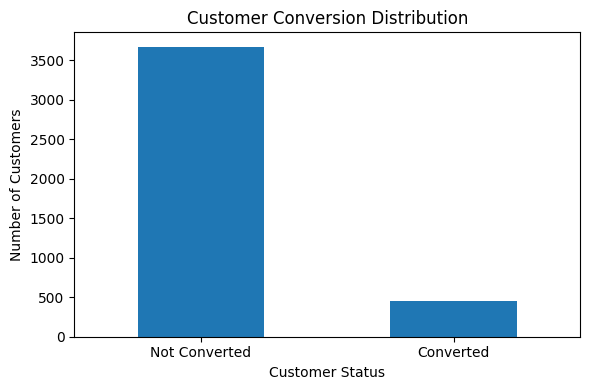

In [11]:
import matplotlib.pyplot as plt
counts = data['y'].value_counts()
counts.plot(kind='bar', figsize=(6,4))
plt.title("Customer Conversion Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ['Not Converted', 'Converted'], rotation=0)
plt.tight_layout()
plt.show()

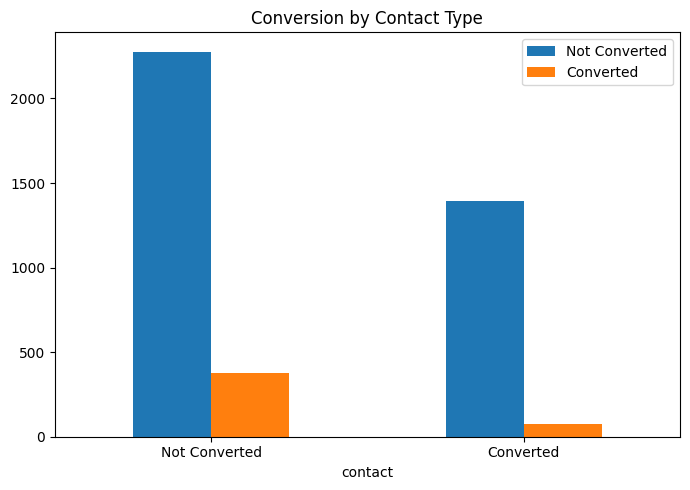

In [14]:
import matplotlib.pyplot as plt
ct = pd.crosstab(data['contact'], data['y'])
ct.columns = ['Not Converted', 'Converted']
ct.plot(kind='bar', figsize=(7,5))
plt.title("Conversion by Contact Type")
plt.xticks([0, 1], ['Not Converted', 'Converted'], rotation=0)
plt.tight_layout()
plt.show()

# Titles

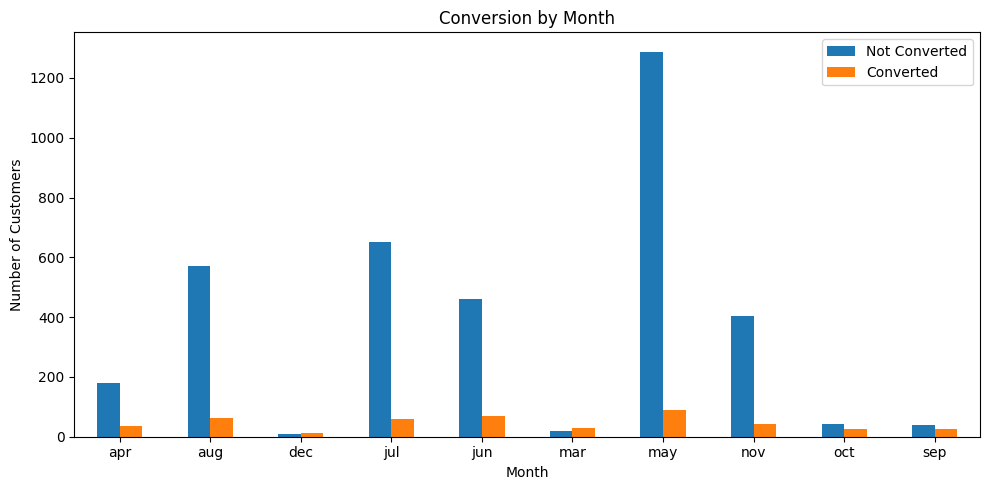

In [16]:
import matplotlib.pyplot as plt
ct_month = pd.crosstab(data['month'], data['y'])
ct_month.columns = ['Not Converted', 'Converted']
ct_month.plot(kind='bar', figsize=(10,5))
plt.title("Conversion by Month")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

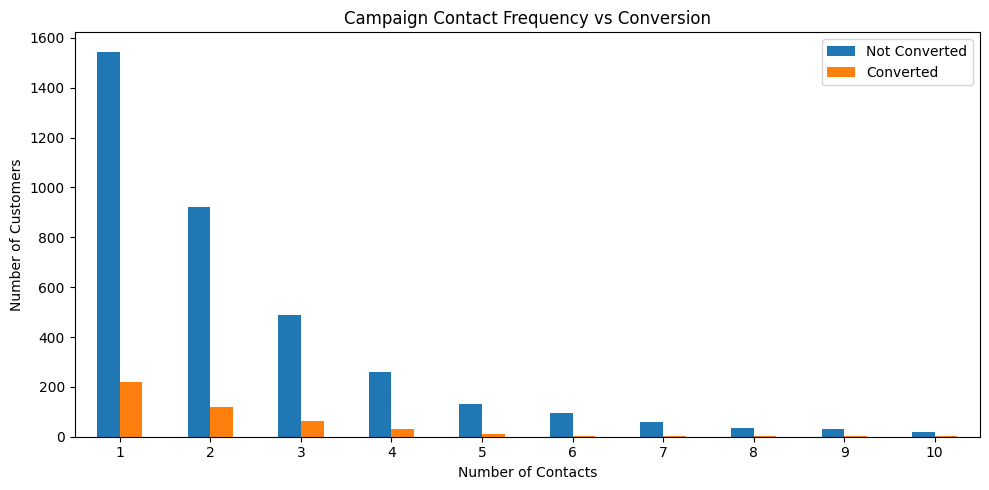

In [17]:
import matplotlib.pyplot as plt
campaign_ct = pd.crosstab(data['campaign'], data['y'])
campaign_ct.columns = ['Not Converted', 'Converted']
campaign_ct = campaign_ct.head(10)
campaign_ct.plot(kind='bar', figsize=(10,5))
plt.title("Campaign Contact Frequency vs Conversion")
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
total = len(data)
converted = (data['y'] == 'yes').sum()
not_converted = (data['y'] == 'no').sum()
conversion_rate = (converted / total) * 100
drop_off_rate = 100 - conversion_rate
print(f"Total Customers: {total}")
print(f"Converted: {converted}")
print(f"Not Converted: {not_converted}")
print(f"Conversion Rate: {conversion_rate:.2f}%")
print(f"Drop-off Rate: {drop_off_rate:.2f}%")

Total Customers: 4119
Converted: 451
Not Converted: 3668
Conversion Rate: 10.95%
Drop-off Rate: 89.05%


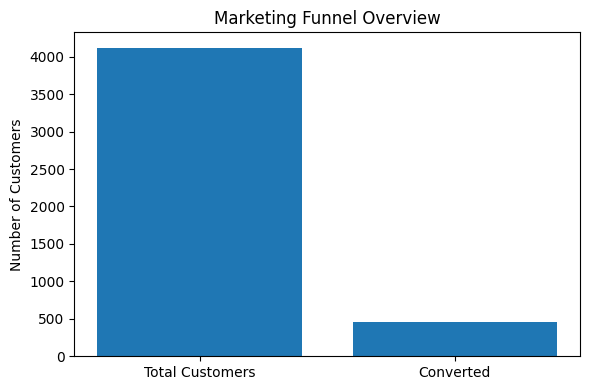

In [19]:
stages = ['Total Customers', 'Converted']
values = [total, converted]
plt.figure(figsize=(6,4))
plt.bar(stages, values)
plt.title("Marketing Funnel Overview")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

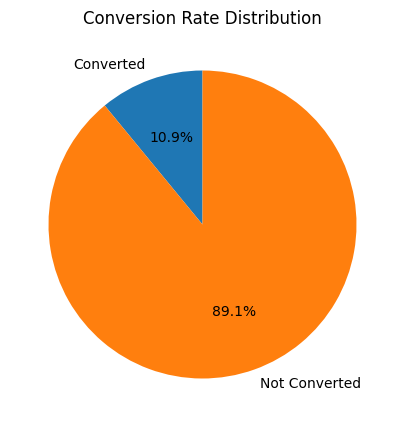

In [20]:
labels = ['Converted', 'Not Converted']
sizes = [converted, not_converted]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Conversion Rate Distribution")
plt.show()